# 🌌 General Relativity Simulator

This notebook calculates the spacetime curvature ($G_{\mu\nu}$) and the energy-momentum source ($T_{\mu\nu}$) based on Einstein's Field Equations.

It allows you to investigate what happens in the vacuum, on the surface, or inside any celestial body.

The Einstein Field Equation:

$$R_{\mu\nu} - \frac{1}{2}R g_{\mu\nu} = \frac{8\pi G}{c^4} T_{\mu\nu}$$

Where the left side represents Geometry (curvature) and the right side represents Matter/Energy (the source).

**Instructions**

Update the `Astro Parameters` values in `Section 3: Physical Constants and Astro-Parameters` section to change the parameters.
Then re-run all the sections after `Section 6: Calculations` to recalculate and see the results.

The `Data` section contains others bodies values to use and links to anothers sites where we can find many more astronomical objects.

In [1]:
import math
import numpy as np
import pandas as pd
import sympy
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import warnings
from copy import copy
from matplotlib.ticker import StrMethodFormatter
from sympy import symbols, diag, sin, diff, simplify, pi, sqrt, Piecewise, Matrix
from IPython.display import display, Math

In [2]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

---

## 📚 Section 1: Theory

### Einstein’s Field Equation

#### 1. Field Equation
Einstein's famous formula:
$$R_{\mu\nu} - \frac{1}{2}R g_{\mu\nu} + \Lambda g_{\mu\nu} = \frac{8\pi G}{c^4} T_{\mu\nu}$$

In this equation:
* the right side tells us how much energy/metter exists
* the left side tells us how the spacetime geometry responds to that matter

The terms are:
* **$T_{\mu\nu}$ (Energy-Momentum Tensor)** represents matter and energy (the "weight" on the fabric).
* **$R_{\mu\nu}$ (Ricci Tensor)** quantifies how much the volume of that matter/energy changes as it travels along a geodesic.
* **$g_{\mu\nu}$ (Metric Tensor)** derivatives (**$R_{\mu\nu}$, the Ricci Tensor**) represent the curvature.
* **$R$ (Ricci Scalar Curvatura)** is the simplest possible that resumes the measument of spacetime curvature.

The equation basically states: **The presence of $T$ (matter) forces $g$ (the metric) to curve.**

From there we can calculate the **Einstein Tensor**:

$$G_{\mu\nu} = R_{\mu\nu} - \frac{1}{2} R g_{\mu\nu}$$

#### 2. What is the Metric ($g_{\mu\nu}$) Intuitively?
Imagine we have a map of a city.
* If the city is flat (**Euclidean Geometry**), the distance between two points is a straight line: $d^2 = x^2 + y^2$.
* Now, imagine this city was built over hills and valleys. The distance "on the map" (2D) no longer corresponds to the actual distance we walk, because we are constantly moving up and down.

The **Metric $g$** is the function that adjusts this calculation. It says: *"At this specific point on the map, for every centimeter we walk north, we are actually ascending 2 centimeters in real space."* It defines the local "fabric" or "weave" of spacetime.

#### 3. The "Ruler" That Changes Size
In flat space (**Special Relativity**), we use the **Minkowski Metric** ($\eta_{\mu\nu}$), where values are fixed ($1$ or $-1$). It is a perfect "grid-like" universe.

In **General Relativity**, the components of $g_{\mu\nu}$ are functions of the coordinates. This means:
* **In strong fields:** The values of $g$ change, which "stretches" or "squeezes" the coordinates.
* **The Invariant Interval ($ds^2$):** The metric allows us to calculate the true "size" of a path in spacetime:
    $$ds^2 = \sum_{\mu,\nu} g_{\mu\nu} dx^\mu dx^\nu$$

This is what causes the **space contraction** and **time dilation** we discussed. If the value of $g$ for the time component ($g_{00}$) changes due to a mass, our clock "feels" this change in the metric and ticks slower.

#### 4. The Physical Fact: The Gravitational Field IS the Metric
Here is the most profound revelation of Einstein’s career: **Gravity is not something that "lives" inside spacetime. Gravity IS the metric of spacetime.**

There is no separate "gravitational field" like a magnetic field. What we call the force of gravity is simply the effect of trying to move in a straight line through a metric $g_{\mu\nu}$ that is warped.

> **Example:** If we throw a ball, it follows a parabolic arc. It doesn't do this because a force "pulls" it down, but because the metric $g$ near the Earth is so curved that the "straightest possible path" (**geodesic**) through spacetime for that ball is a curve that returns to the ground.

#### 5. The Geodesic Equation: Why Things Actually Fall
The term $g_{\mu\nu}$ defines the **shape** of the "grid" and $G_{\mu\nu}$ defines the **curvature**.

But how does an object actually move in that grid?

Objects don't feel a "force" of gravity. Instead, they follow the straightest possible path in a curved geometry, called a **Geodesic**. 

The equation of motion is:

$$\frac{d^2 x^\mu}{d\tau^2} + \Gamma^\mu_{\alpha\beta} \frac{dx^\alpha}{d\tau} \frac{dx^\beta}{d\tau} = 0$$

* **$\Gamma^\mu_{\alpha\beta}$ (Christoffel Symbols):** they act as the "gravitational force" terms.

When we see a planet orbiting a star, it is simply "going straight" in a space where the metric $g_{\mu\nu}$ makes "straight" look like an ellipse to us.

#### 6. The Newtonian Limit: Connecting to $F = ma$
How do these complex tensors relate to the simple gravity we learned in school ($g = 9.8 \, m/s^2$)? 

For weak fields (like Earth's) and slow speeds, the $g_{00}$ component of the metric is directly related to the **Newtonian Gravitational Potential** ($\Phi$):

$$g_{00} \approx -\left(1 + \frac{2\Phi}{c^2}\right)$$

Where $\Phi = -GM/r$. 

In this notebook, if we check the output of $g_{00}$ for Earth, we are literally seeing the Newtonian potential embedded inside the 4th dimension (Time). Gravity is just the "time-gradient" of the metric.

#### 7. The Conservation Law (Bianchi Identity)
One of the most beautiful parts of the Einstein Field Equations is that they automatically satisfy the conservation of energy and momentum.

$$\nabla^\mu T_{\mu\nu} = 0$$

This mathematical identity means that the geometry of the universe *forces* energy and momentum to be conserved. We cannot create or destroy energy because the "shape" of the universe wouldn't allow the math to balance.

### Energy-Momentum Tensor ($T_{\mu\nu}$)

The **Energy-Momentum Tensor** ($T_{\mu\nu}$) is the source of the gravitational field.
While the Einstein Tensor ($G_{\mu\nu}$) describes the "shape" of spacetime, $T_{\mu\nu}$ describes the "stuff" inside it.

$$T_{\mu\nu} \approx \begin{pmatrix} T_{00} & T_{01} & T_{02} & T_{03} \\ T_{10} & T_{11} & T_{12} & T_{13} \\ T_{20} & T_{21} & T_{22} & T_{23} \\ T_{30} & T_{31} & T_{32} & T_{33} \end{pmatrix}$$

To calculate this for planets, stars, or the universe as a whole, physicists usually model matter as a **Perfect Fluid**.

#### 1. What is a Perfect Fluid?
A perfect fluid is an idealized model of matter that is characterized entirely by its **rest-mass density** ($\rho$) and its **isotropic pressure** ($P$). 

* **No Viscosity:** There is no internal friction between layers of the fluid.
* **No Heat Conduction:** Energy does not flow between parts of the fluid due to temperature gradients.

For most astronomical bodies (like Earth or the Sun), this is an incredibly accurate approximation.

#### 2. The Mathematical Formula
The components of the Energy-Momentum Tensor for a perfect fluid are given by:

$$T_{\mu\nu} = \left(\rho + \frac{P}{c^2}\right) u_\mu u_\nu + P g_{\mu\nu}$$

**Where:**
* $\rho$: The energy density (mass per volume times $c^2$).
* $P$: The hydrostatic pressure.
* $u_\mu$: The **four-velocity** of the fluid (how the matter moves through spacetime).
* $g_{\mu\nu}$: The metric tensor (representing the geometry of spacetime).

#### 3. Understanding the Matrix Structure
The tensor $T_{\mu\nu}$ is a $4 \times 4$ symmetric matrix. Each component represents a different physical quantity:

* **$T_{00}$ (Energy Density):** This is the "amount of stuff." In a planet, this is dominated by $\rho c^2$. It is the primary driver of gravity in weak fields.
* **$T_{0i}$ (Energy Flux/Momentum Density):** These represent how energy moves. If the planet is rotating or the fluid is flowing, these terms become non-zero.
* **$T_{ii}$ (Normal Stresses/Pressure):** These are the diagonal spatial components. They represent the internal pressure pushing outward.
* **$T_{ij}$ (Shear Stresses):** In a perfect fluid, these off-diagonal spatial terms are **zero** because there is no viscosity.

#### 4. Step-by-Step Calculation (The Static Case)
If we assume the observer is moving *with* the fluid (the "Comoving Frame"), the calculation simplifies significantly.

##### Step A: Define the Four-Velocity ($u^\mu$)
For a static observer on a planet, the matter isn't moving through space, only through time.
$$u^\mu = \left( \frac{1}{\sqrt{-g_{00}}}, 0, 0, 0 \right)$$
This ensures that the "length" of the four-velocity is always normalized ($u^\mu u_\mu = -c^2$).

##### Step B: Populate the Tensor
In the frame of a static planet, the tensor becomes diagonal:
$$T_{\mu\nu} = \text{diag}(\rho c^2, P, P, P)$$

* **$T_{00} = \rho c^2$**: This tells us how much "energy-mass" is bending time.
* **$T_{ii} = P$**: This tells us how the internal pressure is bending space.

#### 5. Physical Implication: Why Pressure Matters
In Newton’s gravity, only **mass** creates gravity. In Einstein’s gravity, **pressure** also creates gravity.

> **The Neutron Star Fact:** In extremely dense objects like Neutron Stars, the pressure is so high that it actually adds significantly to the gravitational pull. This creates a feedback loop: more pressure $\rightarrow$ more gravity $\rightarrow$ more compression $\rightarrow$ more pressure. This is why there is a limit to how massive a star can be before it **must** collapse into a black hole (the Tolman-Oppenheimer-Volkoff limit).

For a planet like Earth, the ratio $P / \rho c^2$ is roughly $10^{-9}$, which is why we can usually ignore pressure and just look at the mass.


---

### Ricci Tensor ($R_{\mu\nu}$)

The **Ricci Tensor** is a $4 \times 4$ symmetric matrix that describes the curvature of spacetime specifically associated with the presence of matter and energy. 
If the Einstein Field Equation is a sentence, the Ricci Tensor is the core "verb" describing how space is being bent at a specific point.

#### 1. The Geometric Intuition: Volume Distortion
The most intuitive way to understand the Ricci Tensor is through **volume changes**. 

Imagine a small, spherical cloud of test particles (like coffee grounds or dust) floating in space:
* **In Flat Space (Minkowski):** The cloud moves along and maintains its exact volume and spherical shape.
* **In Curved Space (Near a mass):** Gravity deforms the cloud. 

The Ricci Tensor ($R_{\mu\nu}$) quantifies how much the **volume** of that cloud changes as it travels along a geodesic.
It tells us the degree to which a region of spacetime is "deviating" from a flat Euclidean volume due to the matter residing within it.

#### 2. The Mathematical Origin
The Ricci Tensor does not exist in isolation. It is a "contraction" (a simplified version) of a much more complex object called the **Riemann Curvature Tensor** ($R^\rho_{\mu\sigma\nu}$):
* **Riemann Tensor:** Contains all 20 independent pieces of information about 4D curvature.
* **Ricci Tensor:** By summing over certain indices of the Riemann tensor, we focus only on the curvature that is directly coupled to the **Energy-Momentum Tensor** ($T_{\mu\nu}$).

Mathematically, it involves the first and second derivatives of the metric $g_{\mu\nu}$, we calculate the **Christoffel Symbols** first before deriving the Ricci components.

#### 3. Role in the Einstein Field Equation

The Ricci Tensor $R_{\mu\nu}$ works alongside the **Ricci Scalar** ($R$) and the **Metric** ($g_{\mu\nu}$) to form the **Einstein Tensor** ($G_{\mu\nu}$).

Without the Ricci Tensor, we would have no mathematical bridge to translate the physical presence of a star into the geometric warping of the universe.

> **Note on Vacuum:** In a vacuum where no matter is present ($T_{\mu\nu} = 0$), the Ricci Tensor is zero ($R_{\mu\nu} = 0$).
> However, spacetime can still be curved! This is called "Ricci-flat" curvature (like the gravity of the Sun affecting the Earth). In these cases, the curvature is described by the **Weyl Tensor**, which handles tidal forces that change the *shape* of an object without changing its *volume*.


### Metric Tensor ($g_{\mu\nu}$)

The **Metric Tensor** ($g_{\mu\nu}$) is the most fundamental object.
If we think of spacetime as a fabric, the metric tensor is the "ruler" and "clock" that tell we how that fabric is woven.

Without a metric, we cannot measure distances, angles, or time intervals.
It is the mathematical map that turns abstract coordinates into physical reality.

#### 1. The Geometric Intuition
In flat, 2D Euclidean geometry (like a piece of paper), the distance between two points is given by the Pythagorean theorem:
$$dl^2 = dx^2 + dy^2$$

In the 4D spacetime of Special Relativity (Flat Spacetime), we use the **Minkowski Metric** ($\eta_{\mu\nu}$):
$$ds^2 = -c^2 dt^2 + dx^2 + dy^2 + dz^2$$

However, once gravity is present, spacetime becomes **curved**. The grid lines are no longer straight or evenly spaced. The Metric Tensor $g_{\mu\nu}$ is a function that changes at every point in space to account for this stretching and squeezing.

#### 2. The Metric as a "Conversion Tool"
The primary job of the metric is to calculate the **Spacetime Interval** ($ds^2$). This interval is "invariant," meaning all observers—no matter how fast they move—will agree on its value.

$$ds^2 = \sum_{\mu=0}^{3} \sum_{\nu=0}^{3} g_{\mu\nu} dx^\mu dx^\nu$$

* **$dx^\mu$ and $dx^\nu$**: These are small changes in coordinates (like time, radius, or angle).
* **$g_{\mu\nu}$**: These are the "weights." They tell us how much a change in coordinate $r$ actually contributes to a physical distance in meters.

#### 3. Anatomia of the Tensor ($4 \times 4$ Matrix)
The metric is represented as a symmetric matrix. For a spherical body like Earth, the diagonal components are the most important:

$$g_{\mu\nu} = \begin{pmatrix} g_{00} & 0 & 0 & 0 \\ 0 & g_{11} & 0 & 0 \\ 0 & 0 & g_{22} & 0 \\ 0 & 0 & 0 & g_{33} \end{pmatrix}$$

* **$g_{00}$ (The Time Component):** This governs **Gravitational Time Dilation**. If $g_{00}$ is larger (less negative) than usual ($-cˆ2$ or $-1$ in normalized unit), clocks tick slower.
* **$g_{11}$ (The Radial Component):** This describes the **Curvature of Space**. It tells us how "long" a meter is when pointing toward the center of gravity.
* **$g_{22}, g_{33}$ (The Angular Components):** Describe the geometry of spheres ($r^2$ and $r^2 \sin^2\theta$). Even in curved space, the surface of a sphere must still behave like a sphere.

#### 4. Physical Reality: Gravity is the Metric
The most profound conclusion of Einstein's theory is that **gravity is not a force field** living inside spacetime. Instead, **Gravity IS the Metric.**

* When we say an object is "pulled" by gravity, it is actually just moving along the "straightest possible path" (a **geodesic**) in a spacetime where the metric $g_{\mu\nu}$ is curved.
* The **Einstein Field Equations** are essentially a set of instructions: Matter ($T_{\mu\nu}$) tells the Metric ($g_{\mu\nu}$) how to curve.


### Ricci Scalar Curvatura ($R$)

The **Ricci Scalar** (or Scalar Curvature) is the simplest possible measure of spacetime curvature.

While tensors like $g_{\mu\nu}$ and $R_{\mu\nu}$ are complex matrices with many components, the Ricci Scalar is a single number (a scalar) assigned to every point in space that summarizes the "total curvature" of that point in spacetime.

#### 1. The Geometric Intuition: Surface area deviation
The Ricci Scalar tells us how the volume of a 4D ball in curved spacetime differs from the volume of a standard ball in flat Euclidean space.

* **If $R = 0$:** The space is "Ricci-flat." On average, the geometry behaves like flat space (even if it is being stretched in one direction and squeezed in another).
* **If $R > 0$:** The space is "positively curved" (like the surface of a sphere). Parallel lines will eventually meet.
* **If $R < 0$:** The space is "negatively curved" (like a saddle). Parallel lines will diverge.

#### 2. How is it calculated?
Mathematically, $R$ is the **trace** of the Ricci Tensor. We obtain it by "contracting" the Ricci Tensor with the inverse metric:

$$R = g^{\mu\nu} R_{\mu\nu}$$

This process collapses the $4 \times 4$ matrix into a single value that is **invariant**, meaning every observer in the universe will calculate the exact same value for $R$ at that point, regardless of their speed or coordinate system.

#### 3. Role in the Einstein Field Equations
The Ricci Scalar is a vital component of the **Einstein Tensor** ($G_{\mu\nu}$).

It acts as a "correction factor." Einstein discovered that the Ricci Tensor alone ($R_{\mu\nu}$) didn't obey the laws of conservation of energy. By subtracting half of the Ricci Scalar multiplied by the metric, the math finally balanced, ensuring that energy and momentum are never created or destroyed by the geometry of space.

#### 4. Physical Meaning: The Density of Matter
One of the most powerful properties of the Ricci Scalar is its direct relationship to the **Trace of the Energy-Momentum Tensor** ($T_{uv}$).
In many cases:

$$R = -\kappa T$$

This means that if an observer is inside a planet with a certain mass density and pressure, the Ricci Scalar $R$ is literally a map of that density. 

* **Outside a planet (Vacuum):** Since there is no matter ($T=0$), the Ricci Scalar is **exactly zero** ($R=0$).
* **Inside a planet:** $R$ has a non-zero value representing the physical "stuff" occupying that space.


### Einstein Tensor ($G_{\mu\nu}$)

The **Einstein Tensor**, denoted as $G_{\mu\nu}$, is the "heart" of General Relativity.
It represents the specific combination of spacetime curvature that is directly proportional to the energy and momentum of matter.

We can think of $G_{\mu\nu}$ as the **"Geometric Response"** of the universe: it is the signature that matter leaves upon space and time. When we see the numbers in your $G_{\mu\nu}$ matrix change, we are literally seeing the fabric of reality reacting to the mass of the celestial body.

#### 1. The Geometric Intuition: The "Balanced" Curvature
To describe how gravity works, Einstein couldn't just use the Ricci Tensor ($R_{\mu\nu}$) alone. Why? Because the laws of physics require that **energy and momentum must be conserved** (they cannot be created or destroyed). 

Mathematically, the Ricci Tensor doesn't automatically satisfy this conservation. Einstein had to "subtract" a portion of the total curvature ($R$) to ensure the equations worked correctly. The result is the Einstein Tensor:
$$G_{\mu\nu} = R_{\mu\nu} - \frac{1}{2} R g_{\mu\nu}$$

#### 2. The Physical Meaning: "Geography tells matter how to move"
The Einstein Tensor is the bridge between **Geometry** and **Physics**. In the field equation:
$$G_{\mu\nu} + \Lambda g_{\mu\nu} = \frac{8\pi G}{c^4} T_{\mu\nu}$$

* **$G_{\mu\nu}$** represents the **dynamic curvature** caused by the presence of a planet or star.
* **$T_{\mu\nu}$** represents the **matter and energy** causing that curvature.

The $G_{\mu\nu}$ is the mathematical answer to the question: "Given this much mass, what is the exact shape of the local universe?"

#### 3. Why is it a $4 \times 4$ Matrix?
Like the metric, the Einstein Tensor has 16 components (though only 10 are independent due to symmetry).

Each component describes a different "flavor" of curvature:
* **$G_{00}$:** Curvature related to the **density** of energy (Time-Time).
* **$G_{0i}$:** Curvature related to the **momentum** or flow of matter (Time-Space).
* **$G_{ii}$:** Curvature related to the **pressure** or stress within the object (Space-Space).


## 📏 Section 2: Data

To perform the General Relativity (GR) calculations for different celestial bodies, we need three primary values: **Mass ($M$)**, **Radius ($R$)**, and **Average Density ($\rho$)**.

### Celestial Bodies Parameters Table

| Object | Mass ($M$) [kg] | Radius ($R$) [m] | Density ($\rho$) [kg/m³] | Type |
| :--- | :--- | :--- | :--- | :--- |
| **Mercury** | $3.301 \times 10^{23}$ | $2.439 \times 10^{6}$ | $5427$ | Planet |
| **Venus** | $4.867 \times 10^{24}$ | $6.051 \times 10^{6}$ | $5243$ | Planet |
| **Earth** | $5.972 \times 10^{24}$ | $6.371 \times 10^{6}$ | $5514$ | Planet |
| **Mars** | $6.390 \times 10^{23}$ | $3.389 \times 10^{6}$ | $3933$ | Planet |
| **Jupiter** | $1.898 \times 10^{27}$ | $6.991 \times 10^{7}$ | $1326$ | Gas Giant |
| **Saturn** | $5.683 \times 10^{26}$ | $5.823 \times 10^{7}$ | $687$ | Gas Giant |
| **Uranus** | $8.681 \times 10^{25}$ | $2.536 \times 10^{7}$ | $1271$ | Ice Giant |
| **Neptune** | $1.024 \times 10^{26}$ | $2.462 \times 10^{7}$ | $1638$ | Ice Giant |
| **Sun** | $1.989 \times 10^{30}$ | $6.957 \times 10^{8}$ | $1408$ | Star (G-Type) |
| **VY Canis Majoris** | $3.381 \times 10^{31}$ | $9.879 \times 10^{11}$ | $0.000008$ | Red Hypergiant |
| **Stephenson 2-18** | $7.956 \times 10^{31}$ | $1.496 \times 10^{12}$ | $0.000005$ | Red Supergiant |
| **PSR J0030+0451** | $2.864 \times 10^{30}$ | $1.300 \times 10^{4}$ | $3.1 \times 10^{17}$ | Neutron Star |
| **PSR J0740+6620** | $4.137 \times 10^{30}$ | $1.230 \times 10^{4}$ | $5.3 \times 10^{17}$ | Neutron Star |

**💡 Curious Insight**

When we run the code for **Stephenson 2-18** (the largest known star) versus a **Neutron Star**, you will notice a paradox:
* **Stephenson 2-18** is massive, but its density is lower than the air we breathe! Its gravity at the surface is actually quite weak because the surface is so far from the center.
* **Neutron Stars** have nearly the same mass as the Sun but are the size of a city. Their $g_{00}$ will show extreme time dilation ($t \approx 0.7s$ for every $1s$ in space), while for the giant star, time dilation is almost negligible.

### 🔍 How to find this data on Wikipedia
Search for any celestial body on Wikipedia, look at the **"Infobox"**  to locate the following fields:

1.  **Mass:** Usually listed in kilograms ($kg$) or relative to Earth ($M_\oplus$) or the Sun ($M_\odot$).
2.  **Mean Radius:** Use the "Mean radius" or "Equatorial radius" in kilometers ($km$) and convert to meters ($m$).
3.  **Mean Density:** Listed in $g/cm^3$ or $kg/m^3$.
    * *Note:* If density is not listed, you can calculate it using $\rho = \frac{M}{\frac{4}{3}\pi R^3}$.

### Useful Data Sources (Links)

* **[NASA Planetary Fact Sheet](https://nssdc.gsfc.nasa.gov/planetary/factsheet/):** The best source for solar system planets.
* **[NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/):** Detailed data on stars and planets outside our system.
* **[SIMBAD Astronomical Database](http://simbad.u-strasbg.fr/simbad/):** The professional portal for data on stars.

### Data Conversion

In the Wikipedia "Infobox":
- masses are frequently given in Solar Masses ($M_\odot$) for stars or Earth Masses ($M_\oplus$) for planets
- Radii are often in kilometers ($km$) or Solar Radii ($R_\odot$)

The function `calculate_density` is essential because for many distant objects (like hypergiant stars), the exact density is not measured directly; it is derived from the estimated mass and volume.

**Constants for Conversion**

Source: NASA Planetary Fact Sheet / IAU Constants

In [3]:
SOLAR_MASS = 1.98847e30      # 1 M_sun in kg
EARTH_MASS = 5.9722e24       # 1 M_earth in kg
JUPITER_MASS = 1.8982e27     # 1 M_jupiter in kg

SOLAR_RADIUS = 6.957e8       # 1 R_sun in m
EARTH_RADIUS = 6.371e6       # 1 R_earth in m

In [4]:
def get_si_units(value, unit_type):
    """
    Converts astronomical units to SI (kg, m).
    Example: get_si_units(1.0, 'M_sun') -> 1.988e30
    """
    conversions = {
        'kg': 1.0,
        'm': 1.0,
        'km': 1000.0,
        'M_sun': SOLAR_MASS,
        'M_earth': EARTH_MASS,
        'M_jupiter': JUPITER_MASS,
        'R_sun': SOLAR_RADIUS,
        'R_earth': EARTH_RADIUS
    }
    return value * conversions.get(unit_type, 1.0)

In [5]:
def calculate_density(mass_kg, radius_m):
    """
    Calculates mean density (rho) if not provided by Wikipedia.
    Formula: rho = mass / volume
    """
    volume = (4/3) * np.pi * (radius_m**3)
    return mass_kg / volume

In [6]:
def prepare_astro_body(name, mass, mass_unit, radius, radius_unit, density=None):
    """
    Main helper to prepare data for the Einstein Field Equations.
    Returns a dictionary with SI values.
    """
    m_si = get_si_units(mass, mass_unit)
    r_si = get_si_units(radius, radius_unit)
    
    if density is None:
        rho_si = calculate_density(m_si, r_si)
    else:
        # Assuming density provided in kg/m^3, if in g/cm^3 multiply by 1000
        rho_si = density 

    return {
        'name': name,
        'M': m_si,
        'R': r_si,
        'rho': rho_si
    }

**Example of How To Use**

Note how the density of Stephenson 2-18 is extremely low ($10^{-5}$ to $10^{-6}$ range), reflecting its "puffy" nature, while the Neutron Star reaches $10^{17} \text{ kg/m}^3$, the density of an atomic nucleus.

In [7]:
# --- EXAMPLE 1: Earth ---
stephenson = prepare_astro_body(
    name="Stephenson 2-18",
    mass=40.0, mass_unit='M_sun',
    radius=2150.0, radius_unit='R_sun'
)

List of celestial objects with parameters in SI units.

In [8]:
# Format: Name, Mass (kg), Radius (m), Density (kg/m^3), Type
celestial_bodies = [
    {"name": "Mercury", "M": 3.301e23, "R": 2.439e6, "rho": 5427, "type": "Planet"},
    {"name": "Venus", "M": 4.867e24, "R": 6.051e6, "rho": 5243, "type": "Planet"},
    {"name": "Earth", "M": 5.972e24, "R": 6.371e6, "rho": 5514, "type": "Planet"},
    {"name": "Mars", "M": 6.390e23, "R": 3.389e6, "rho": 3933, "type": "Planet"},
    {"name": "Jupiter", "M": 1.898e27, "R": 6.991e7, "rho": 1326, "type": "Planet (Gas Giant)"},
    {"name": "Saturn", "M": 5.683e26, "R": 5.823e7, "rho": 687, "type": "Planet (Gas Giant)"},
    {"name": "Uranus", "M": 8.681e25, "R": 2.536e7, "rho": 1271, "type": "Planet (Ice Giant)"},
    {"name": "Neptune", "M": 1.024e26, "R": 2.462e7, "rho": 1638, "type": "Planet (Ice Giant)"},
    {"name": "Sun", "M": 1.989e30, "R": 6.957e8, "rho": 1408, "type": "Star (G-Type)"},
    {"name": "VY Canis Majoris", "M": 3.381e31, "R": 9.879e11, "rho": 8.0e-6, "type": "Red Hypergiant"},
    {"name": "Stephenson 2-18", "M": 7.956e31, "R": 1.496e12, "rho": 5.0e-6, "type": "Red Supergiant"},
    {"name": "PSR J0030+0451", "M": 2.864e30, "R": 1.300e4, "rho": 3.1e17, "type": "Neutron Star"},
    {"name": "PSR J0740+6620", "M": 4.137e30, "R": 1.230e4, "rho": 5.3e17, "type": "Neutron Star"},
]

earth = celestial_bodies[2]
sun = celestial_bodies[8]
neutron_star = celestial_bodies[-1]

In [9]:
for body in [earth, sun, neutron_star, stephenson]:
    print(f"{body['name']}:")
    print(f"  SI Mass: {body['M']:.2e} kg")
    print(f"  SI Radius: {body['R']:.2e} m")
    print(f"  Calculated Density: {body['rho']:.2e} kg/m^3\n")

Earth:
  SI Mass: 5.97e+24 kg
  SI Radius: 6.37e+06 m
  Calculated Density: 5.51e+03 kg/m^3

Sun:
  SI Mass: 1.99e+30 kg
  SI Radius: 6.96e+08 m
  Calculated Density: 1.41e+03 kg/m^3

PSR J0740+6620:
  SI Mass: 4.14e+30 kg
  SI Radius: 1.23e+04 m
  Calculated Density: 5.30e+17 kg/m^3

Stephenson 2-18:
  SI Mass: 7.95e+31 kg
  SI Radius: 1.50e+12 m
  Calculated Density: 5.67e-06 kg/m^3



---

## 🛠️ Section 3: Physical Constants and Astro-Parameters

### Physical Constants

In [10]:
G_const = 6.674e-11
c_const = 299792458

### Einstein's Constant (_kappa_, $\kappa$)

The "stiffness" of spacetime. It is on the order of $10^{-43}$.

This explains why gravity is so weak: 
- we need an ABSURD amount of energy ($T_{\mu\nu}$) to produce a minimally detectable curvature ($G_{\mu\nu}$).

In [11]:
kappa_val = (8 * pi * G_const) / (c_const**4)

display(Math(rf"\kappa = {kappa_val.evalf():.2e}"))

<IPython.core.display.Math object>

### Simulation Parameters

Parameters:

- `M_val`: the mass $M$ in $kg$
- `R_val`: the radius $R$ in $m$
- `rho_val`: the density $\rho$ in $kg/m^3$
- `P_val`: the surface pressure $P$ in $Pa$
- `r_obs_val`: the observer radius $r$ in $m$

Change `r_obs_val`:

- Surface: `= R_val`
- Orbit/vacuum: `> R_val`
- Interior: `< R_val`

#### Astro Parameters

Change here if you have the direct values

In [12]:
# --- Example of Earth ---
M_val = 5.972e24      # Mass (kg)
R_val = 6.371e6       # Object Radius (m)
rho_val = 5515        # Average Density (kg/m^3)
P_val = 101325        # Surface Pressure (Pa)

#### Observer Position

In [13]:
r_obs_val = 6.371e6   # Object radius for surface

#### Convert Values

Change here if you want to convert values:

In [14]:
# copied from Wikipedia
wipidedia_params = prepare_astro_body(
    name="Stephenson 2-18",
    mass=40.0, mass_unit='M_sun',
    radius=2150.0, radius_unit='R_sun'
)
wipidedia_params

{'name': 'Stephenson 2-18',
 'M': 7.95388e+31,
 'R': 1495755000000.0,
 'rho': 5.6742574350383095e-06}

#### Initialize the Parameters With Other Values

Change here to initialize the parameteres with converted values or one of the examples

In [15]:
# use one of the examples
active_body = earth

# use converted values
# active_body = wipidedia_params

# Update the simulation dictionary
obj_name = active_body['name']
M_val = active_body['M']
R_val = active_body['R']
rho_val = active_body['rho']
r_obs_val = active_body['R'] # Observer at surface

### Parameteres to Simulation

In [16]:
display(Math(rf"\text{{Mass }} (M) = \text{{{M_val}}}\ kg"))
display(Math(rf"\text{{Radius }} (R) = \text{{{R_val:.6e}}}\ m"))
display(Math(rf"\text{{Density }} (\rho) = \text{{{R_val:.6e}}}\ kg/m^3"))
display(Math(rf"\text{{Surface pressure }} (P) = \text{{{P_val:.6e}}}\ Pa"))
display(Math(rf"\text{{Observer radius }} (R) = \text{{{r_obs_val:.6e}}}\ m"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 📐 Section 4: The Metric $g_{\mu\nu}$ (The DNA of Spacetime)

The metric defines how time and space behave. Inside the body, gravity doesn't depend on the total mass, but only on the mass "below" the observer.

**Physical Note:** In the interior ($r < R$), time ($g_{00}$) passes even slower than on the surface, and space ($g_{11}$) is stretched by the local density.

In [17]:
t, r, theta, phi = symbols('t r theta phi')
M, G, c, R_obj, rho = symbols('M G c R_obj rho')
coords = [t, r, theta, phi]

Schwarzschild Radius (The theoretical Event Horizon)

In [18]:
rs = 2 * G * M / c**2

### Defining Variable _F_ (Interior/Exterior Transition)

#### Exterior (Schwarzschild Vacuum)

In [19]:
f_ext = 1 - rs / r

#### Interior (Static Fluid of Constant Density)

$g_{00}$ (Time) and $g_{11}$ (Space) change to reflect the presence of matter.

This ensures the metric is continuous at the surface ($r = R$).

In [20]:
f_int_time = (1.5 * sqrt(1 - rs/R_obj) - 0.5 * sqrt(1 - rs * r**2 / R_obj**3))**2
f_int_radial = 1 / (1 - rs * r**2 / R_obj**3)

#### Constructing the Metric $g_{\mu\nu}$ using Piecewise logic

In [21]:
g00 = Piecewise((-(f_ext) * c**2, r > R_obj), (-f_int_time * c**2, True))
g11 = Piecewise((1/f_ext, r > R_obj), (f_int_radial, True))

g = diag(g00, g11, r**2, r**2 * sin(theta)**2)
g_inv = g.inv()

---

## ⚙️ Section 5: The Einstein Tensor ($G_{\mu\nu}$)

We calculate the **Christoffel Symbols** (acceleration/gravity), the **Ricci Tensor** (volume curvature), and finally the **Einstein Tensor**.

1.  **$g$**: This is the metric. It’s the "ground truth" of the simulation.
2.  **`g_inv` ($g^{\mu\nu}$)**: The inverse metric. It is mathematically required to "raise indices" and calculate how things move across the grid.
3.  **$R_{00}$**: Represents the curvature related to energy density (the "time-time" component).
4.  **$R_{ii}$**: Represents the curvature related to internal pressure and spatial stress.
5.  **`diff(g, coords)`**: By calculating how the metric changes from one millimeter to the next, we derive the **Christoffel Symbols**, which represent the actual gravitational "pull" we feel.

**1. Christoffel Symbols (Gamma):**

Describes how the metric changes from point to point.

Physically, these represent "inertial forces" or the gravitational field.

**2. Ricci Tensor ($R_{\mu\nu}$):**

Measures the change in volume as we move through spacetime.

**3. Einstein Tensor ($G_{\mu\nu}$):**

This is the pure curvature. It tells space how to bend.

In [22]:
def calculate_physics():
    # 1. Christoffel Symbols (Gamma)
    gamma = sympy.MutableDenseNDimArray.zeros(4, 4, 4)
    for a in range(4):
        for b in range(4):
            for i in range(4):
                res = 0
                for d in range(4):
                    res += 0.5 * g_inv[a, d] * (diff(g[d, b], coords[i]) + 
                           diff(g[d, i], coords[b]) - diff(g[b, i], coords[d]))
                gamma[a, b, i] = res

    # 2. Ricci Tensor (R_mu_nu)
    ricci = Matrix.zeros(4, 4)
    for mu in range(4):
        for nu in range(4):
            r_val = 0
            for rho_idx in range(4):
                r_val += diff(gamma[rho_idx, mu, nu], coords[rho_idx])
                r_val -= diff(gamma[rho_idx, mu, rho_idx], coords[nu])
                for sigma in range(4):
                    r_val += gamma[rho_idx, mu, nu] * gamma[sigma, rho_idx, sigma]
                    r_val -= gamma[sigma, mu, rho_idx] * gamma[rho_idx, nu, sigma]
            ricci[mu, nu] = r_val

    # 3. Einstein Tensor (G_mu_nu)
    R_scalar = sum(g_inv[i, i] * ricci[i, i] for i in range(4))
    return ricci - 0.5 * R_scalar * g

The $G_{\mu\nu}$ is our engine:

1. When we input the mass of the **Sun** or a **Neutron Star**, the it calculates the Metric ($g$), then the Ricci Tensor ($R_{\mu\nu}$), and finally the Einstein Tensor ($G$).
2. If we are in a **Vacuum**, we will notice that $G_{\mu\nu}$ is **zero** (assuming the Cosmological Constant $\Lambda$ is zero).
3. Inside the object, the values of $G_{\mu\nu}$ will be non-zero and will match the density and pressure of the body you are simulating.

In [23]:
G_tensor = calculate_physics()

To see the details of the [complicated] tensor:

In [24]:
# G_tensor

---

## ✏ Section 6: Calculations

### Equation Resolution

We compare the Geometry ($G_{00}$) with the Matter/Energy source ($\kappa T_{00}$) at the observer's specific position.

In [25]:
def resolve_equation_with(values_dict):
    # Left Side: Geometry
    G00_value = G_tensor[0,0].subs(values_dict).evalf()
    
    # Right Side: Matter (T00)
    # In a vacuum (r > R), T00 is zero. Inside, it is the energy density.
    if r.subs(values_dict).evalf() > R_obj.subs(values_dict).evalf():
        T00_value = 0.0
    else:
        T00_value = rho.subs(values_dict).evalf() * (c_const**2)
    
    kappa_T00_value = kappa_val.evalf() * T00_value
    return G00_value, T00_value, kappa_T00_value

### Calculates The Tensors For Test Subject

Numerical substitution with the parameters:

In [26]:
subs_dict = {
    G: G_const,
    c: c_const,
    M: M_val,
    R_obj: R_val,
    rho: rho_val,
    r: r_obs_val
}

In [27]:
G00_val, T00_val, kappa_T00_val = resolve_equation_with(subs_dict)

Relativistic Report for observer.

In [28]:
print(f"At radius r = {r_obs_val/1000} km")

At radius r = 6371.0 km


In [29]:
display(Math(rf"G_{{00}}\ (\text{{Geometry}}) = {G00_val:.6e}"))
display(Math(rf"T_{{00}}\ (\text{{Energy/mass}}) = {T00_val:.6e}"))
if kappa_T00_val == 0:
    display(Math(rf"\kappa T_{{00}}\ (\text{{Matter Source}}) = {kappa_T00_val}"))
else:
    display(Math(rf"\kappa T_{{00}}\ (\text{{Matter Source}}) = {kappa_T00_val:.6e}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 💡 Section 7: Physical Conclusions

Tensor Interpretation Guide:

- **$g_{00}$ (Temporal Metric):** This is the component of the "4th dimension".
    - If the value (divided by $c^2$) is, for example, $-0.9999999986$, it means Earth's gravity is "stealing" time.
    - At the center of the Earth, this value is even lower.
- **$G_{00}$ (Curvatura):** Represents the local energy density.
    - If you are in a vacuum, it must be zero. If it's not zero, Einstein's Equation tells you "there must be something (matter/energy) there."
- **$\kappa T_{00}$ (Source):** This is the "reality check."
    - We multiply the planet's energy density ($\rho c^2$) by Einstein's constant ($\kappa$).
    - The fact that this matches $G_{00}$ in the code is what proves that General Relativity accurately describes the universe.

The further this is from $-1.0000$, the slower time passes compared to deep space.

Undersanding the values:

In [30]:
if r_obs_val > R_val:
    print("LOCATION: Orbit/vacuum (Exterior).")
    print(f"CONCLUSION: G00 ≈ 0. Einstein's equation confirms there is no matter here.")
    print("Space is still curved, but the curvature is 'inherited' from the central mass.")
elif r_obs_val == R_val:
    print("LOCATION: SURFACE. The critical transition point.")
    print("CONCLUSION: Here, geometry finally 'touches' matter.")
    print("The curvature instantly matches the density of the planet's crust.")
else:
    print("LOCATION: INTERIOR. You are surrounded by mass.")
    print("CONCLUSION: G00 and kappa*T00 match perfectly.")
    print("The local matter is actively bending the space right where you are.")

LOCATION: SURFACE. The critical transition point.
CONCLUSION: Here, geometry finally 'touches' matter.
The curvature instantly matches the density of the planet's crust.


In [31]:
g00_val = g[0,0].subs(subs_dict).evalf() / (c_const**2)
display(Math(rf"g_{{00}} = {g00_val:.10f}"))

<IPython.core.display.Math object>

### 🕐 Time Dilation Comparison

#### 1. The Temporal Component ($g_{00}$)

In absolute vacuum (Minkowski space), time passes at a standard rate, where $g_{00} = -1$ (or $-c^2$ depending on the convention).
Any mass present "decreases" this value, causing time dilation.

When a mass (like a planet) is present, it "sinks" into the fabric of spacetime, decreasing the value of $g_{00}$.
This numerical drop is the physical manifestation of **Gravitational Time Dilation**. 

* **$g_{00} \rightarrow -1$:** Time flows at its maximum speed (Vacuum).
* **$g_{00} \rightarrow 0$:** Time flows slower (High Gravity).
* **$g_{00} = 0$:** Time effectively "stops" relative to the outside world (Event Horizon).

#### 2. Calculation Logic: Deviation from the Vacuum
To visualize how much a celestial body "distorts" reality, we calculate the **Vacuum Deviation Percentage**. This tells us how far the local spacetime geometry has shifted away from the perfect flatness of the Minkowski vacuum.

##### The Formula:
$$\text{Time Factor} = \sqrt{1 - \frac{r_s}{R}}$$

**Why use the Square Root?**
In the metric $ds^2$, the components are squared. By taking the square root of the ratio, we move from the "geometry of intervals" back to the "flow of time" ($\Delta \tau / \Delta t$).

#### 3. Interpreting the Deviation Scale

| Deviation (%) | Physical Meaning | Examples |
| :--- | :--- | :--- |
| **0%** | **Perfect Vacuum.** Spacetime is a flat. | Deep intergalactic space. |
| **0.00000007%** | **Negligible Warp.** The geometry is nearly flat. | Surface of the **Earth**. |
| **0.0002%** | **Measurable Warp.** Light begins to bend noticeably. | Surface of the **Sun**. |
| **15% - 40%** | **Extreme Distortion.** Time flows significantly slower. | **Neutron Stars** (PSR J0740+6620). |
| **100%** | **Total Geometric Collapse.** The metric breaks down. | **Black Hole** Event Horizon. |

In [32]:
def calculate_vacuum_deviation(values_dict, g00_value):
    """
    Calculates how much the spacetime at the observer's location 
    deviates from a perfect vacuum (Minkowski space).
    """
    # Schwarzschild radius: rs = 2GM / c^2
    rs = (2 * G_const * values_dict[M]) / (c_const**2)
    
    # 2. Dilation factor: sqrt(1 - rs/R)
    # Approximating to 1 means there isn't much dilation
    time_ratio = np.sqrt(1 - rs / values_dict[R_obj])
    time_dilation_pct = (1 - time_ratio) * 100
    
    return time_dilation_pct

In [33]:
deviation = calculate_vacuum_deviation(subs_dict, g00_val)

Vacuum deviation analysis:

In [34]:
print(f"Deviation from Vacuum: {deviation:.20f}%")

Deviation from Vacuum: 0.00000006960765297492%


### 🍅 Gravitational Acceleration ($g$)

In General Relativity, gravity is the curvature of the metric.
The acceleration felt by a stationary observer is given by:

$$g_{rel} = \frac{c^2 \cdot \Gamma^r_{tt}}{g_{rr} \cdot \sqrt{-g_{tt}}}$$

For weak fields (like planets), this simplifies to Newton's famous formula.:

$$g \approx \frac{GM}{r^2}$$

However, in extreme objects such as neutron stars, the relativistic formula shows that gravity is stronger than Newton predicted, due to the extra curvature of space.

By calculating the Christoffel Symbols ($\Gamma^r_{tt}$), we can extract the acceleration felt by a static observer.

For Earth-like bodies, $g \approx GM/r^2$.
But for compact objects like Neutron Stars, the Metric Correction (the $1/\sqrt{1-r_s/R}$ term) becomes significant, showing that space-time curvature effectively makes gravity "stronger" than Newton predicted.

In [35]:
def estimate_gravity(values_dict):
    """
    Estimates the gravitational acceleration (g) on the surface.
    Compares General Relativity (GR) with Newtonian Gravity.
    """
    # 1. Newtonian Gravity: g = GM / r^2
    g_newton = (G_const * values_dict[M]) / (values_dict[R_obj]**2)
    
    # 2. Relativistic Correction Factor
    # For Schwarzschild metric, the correction is 1 / sqrt(1 - rs/R)
    rs_val = (2 * G_const * values_dict[M]) / (c_const**2)
    correction = 1 / np.sqrt(1 - rs_val / values_dict[R_obj])
    
    g_rel = g_newton * correction
    
    return g_newton, g_rel

Compare the Newtonian gravity with differents objects:

In [36]:
bodies_to_test = [
    earth,
    sun,
    neutron_star,
    {
        "name": obj_name,
        "M": M_val,
        "R": R_val,
        "rho": rho_val
    }
]

print(f"{'Object':<20} | {'Newton g (m/s²)':<24} | {'GR g (m/s²)':<24} | {'Difference (%)'}")
print("-" * 83)

for b in bodies_to_test:
    subs_dict_body = {
        G: G_const,
        c: c_const,
        M: b['M'],
        R_obj: b['R'],
        rho: b['rho'],
        r: b['R']
    }
    gn, gr = estimate_gravity(subs_dict_body)
    diff = ((gr - gn) / gn) * 100
    print(f"{b['name']:<20} | {gn:<24.10f} | {gr:<24.10f} | {diff:.10f}%")

Object               | Newton g (m/s²)          | GR g (m/s²)              | Difference (%)
-----------------------------------------------------------------------------------
Earth                | 9.8195320328             | 9.8195320397             | 0.0000000696%
Sun                  | 274.2691614596           | 274.2697437450           | 0.0002123044%
PSR J0740+6620       | 1824994249454.6894531250 | 2579700540694.1030273438 | 41.3538996884%
Earth                | 9.8195320328             | 9.8195320397             | 0.0000000696%


## ✨ Section 8: Calculate The Tensors For All Celestial Bodies

In [37]:
results = []
for celestial_body in celestial_bodies:
    subs_dict_obj = {
        G: G_const,
        c: c_const,
        M: celestial_body['M'],
        R_obj: celestial_body['R'],
        rho: celestial_body['rho'],
        r: celestial_body['R']
    }
    
    obj_G00_val, obj_T00_val, obj_kappa_T00_val = resolve_equation_with(subs_dict_obj)
    obj_g00_val = g[0,0].subs(subs_dict_obj).evalf() / (c_const**2)
    obj_deviation = calculate_vacuum_deviation(subs_dict_obj, obj_g00_val)

    obj_gn, obj_gr = estimate_gravity(subs_dict_obj)

    item = copy(celestial_body)
    item['object'] = f"{item['name']} ({item['type']})"
    item['r'] = celestial_body['R']

    item['g_newton'] = obj_gn
    item['g_relativistic'] = obj_gr
    item['G_00'] = obj_G00_val
    item['T_00'] = obj_T00_val
    item['kappa_T_00'] = obj_kappa_T00_val
    item['g_00'] = obj_g00_val
    item['time_dilation'] = obj_deviation
    
    results.append(item)

In [38]:
df_results = pd.DataFrame(results)
df_results = df_results[['object', 'M', 'R', 'rho', 'r', 'g_newton', 'g_relativistic', 'G_00', 'T_00', 'kappa_T_00', 'g_00', 'time_dilation']].set_index("object")
df_results.shape

(13, 11)

In [39]:
def format_col_value(col_name, val):
    if col_name == "time_dilation":
        return f"{val:.4e}"
    elif col_name in ['g_newton', 'g_relativistic']:
        return f"{val:.5e}"
    return f"{val:.6e}"

def format_table(df):    
    df['g_newton'] = df['g_newton'].map(lambda v: format_col_value('g_newton', v))
    df['g_relativistic'] = df['g_relativistic'].map(lambda v: format_col_value('g_relativity', v))
    df['G_00'] = df['G_00'].map(lambda v: format_col_value('G_00', v))
    df['T_00'] = df['T_00'].map(lambda v: format_col_value('T_00', v))
    df['kappa_T_00'] = df['kappa_T_00'].map(lambda v: format_col_value('kappa_T_00', v))
    df['g_00'] = df['g_00'].map(lambda v: format_col_value('g_00', v))
    df['time_dilation'] = df['time_dilation'].map(lambda v: format_col_value('time_dilation', v))

    return df.rename(columns={
        'M': 'Mass (kg)',
        'R': 'Radius (m)',
        'rho': 'Density (kg/m^3)',
        'r': 'Observer Radius (m)',
        'g_newton': 'Newtonian Gravity (m/s^2)',
        'g_relativistic': 'Relativistic Gravity (m/s^2)',
        'G_00': 'Einsten Tensor (G_00)',
        'T_00': 'Ricci Tensor (T_00)',
        'kappa_T_00': 'Kappa Energy Density (Kappa T_00)',
        'g_00': 'Metric Tensor (g_00)',
        'time_dilation': 'Time Dilation (%)'
    })

### Celestial Bodies Comparision

In [40]:
df_table = df_results.copy()
format_table(df_table)

,Mass (kg),Radius (m),Density (kg/m^3),Observer Radius (m),Newtonian Gravity (m/s^2),Relativistic Gravity (m/s^2),Einsten Tensor (G_00),Ricci Tensor (T_00),Kappa Energy Density (Kappa T_00),Metric Tensor (g_00),Time Dilation (%)
object,,,,,,,,,,,
Mercury (Planet),3.301000e+23,2.439000e+06,5.427000e+03,2.439000e+06,3.70346e+00,3.703464e+00,9.110613e-6,4.877544e+20,1.012848e-22,-1.000000e+0,1.0050e-08
Venus (Planet),4.867000e+24,6.051000e+06,5.243000e+03,6.051000e+06,8.87142e+00,8.871422e+00,8.796651e-6,4.712173e+20,9.785083e-23,-1.000000e+0,5.9728e-08
Earth (Planet),5.972000e+24,6.371000e+06,5.514000e+03,6.371000e+06,9.81953e+00,9.819532e+00,9.247715e-6,4.955736e+20,1.029085e-22,-1.000000e+0,6.9608e-08
Mars (Planet),6.390000e+23,3.389000e+06,3.933000e+03,3.389000e+06,3.71316e+00,3.713162e+00,6.573908e-6,3.534804e+20,7.340212e-23,-1.000000e+0,1.4001e-08
Jupiter (Planet (Gas Giant)),1.898000e+27,6.991000e+07,1.326000e+03,6.991000e+07,2.59181e+01,2.591814e+01,2.224415e-6,1.191749e+20,2.474732e-23,-1.000000e+0,2.0161e-06
Saturn (Planet (Gas Giant)),5.683000e+26,5.823000e+07,6.870000e+02,5.823000e+07,1.11859e+01,1.118588e+01,1.152590e-6,6.174448e+19,1.282158e-23,-1.000000e+0,7.2473e-07
Uranus (Planet (Ice Giant)),8.681000e+25,2.536000e+07,1.271000e+03,2.536000e+07,9.00860e+00,9.008603e+00,2.131373e-6,1.142318e+20,2.372085e-23,-1.000000e+0,2.5419e-07
Neptune (Planet (Ice Giant)),1.024000e+26,2.462000e+07,1.638000e+03,2.462000e+07,1.12748e+01,1.127483e+01,2.747725e-6,1.472161e+20,3.057022e-23,-1.000000e+0,3.0886e-07
Sun (Star (G-Type)),1.989000e+30,6.957000e+08,1.408000e+03,6.957000e+08,2.74269e+02,2.742697e+02,2.365399e-6,1.265447e+20,2.627770e-23,-9.999958e-1,2.1230e-04


### Newtonian Gravity vs Relativistic Gravity

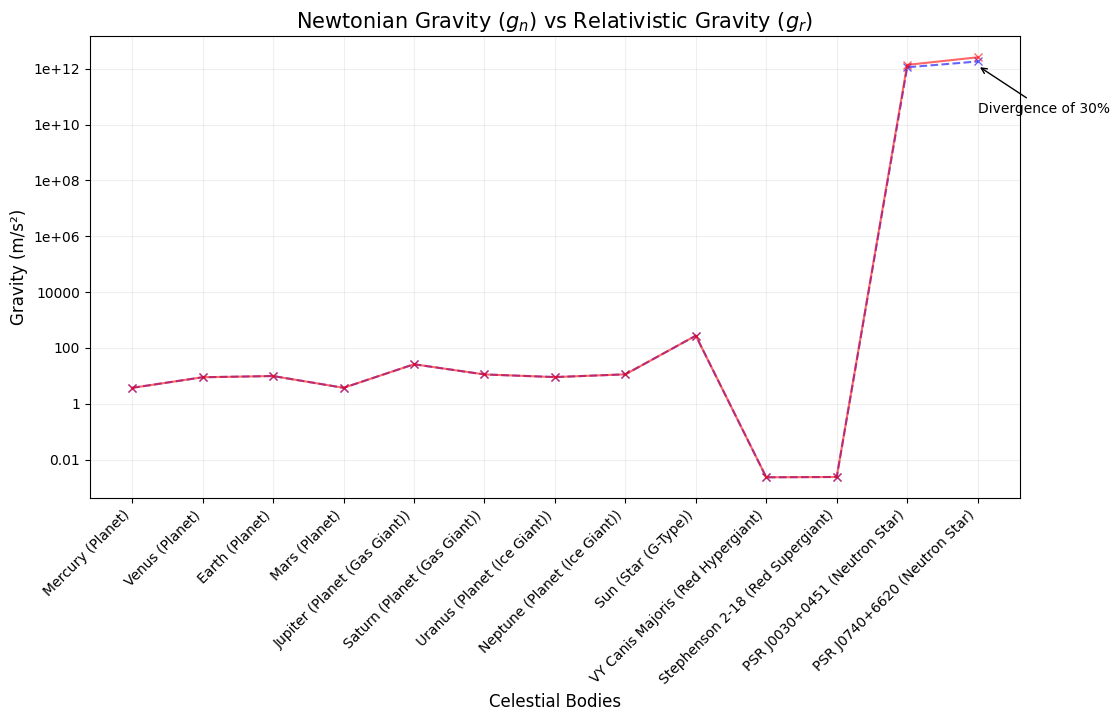

In [41]:
plt.figure(figsize=(12, 6))
plt.title('Newtonian Gravity ($g_n$) vs Relativistic Gravity ($g_r$)', fontsize=15)
plt.ylabel('Gravity (m/s²)', fontsize=12)
plt.xlabel('Celestial Bodies', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))

plt.grid(axis='y', which='both', linestyle='--', alpha=0.5)
plt.grid(True, which="both", ls="-", alpha=0.2)

labels = df_results.index.values
gn_values = df_results['g_newton']
gr_values = df_results['g_relativistic']

plt.plot(labels, gn_values, marker='x', linestyle='--', color='blue', alpha=0.6)
plt.plot(labels, gr_values, marker='x', linestyle='-', color='red', alpha=0.6)

plt.annotate('Divergence of 30%',
             xy=(labels[-1], gr_values[-1]/2),
             xytext=(labels[-1], gr_values[-1]/100),
             arrowprops=dict(arrowstyle='->'))

plt.show()

### Time Dilation Comparision

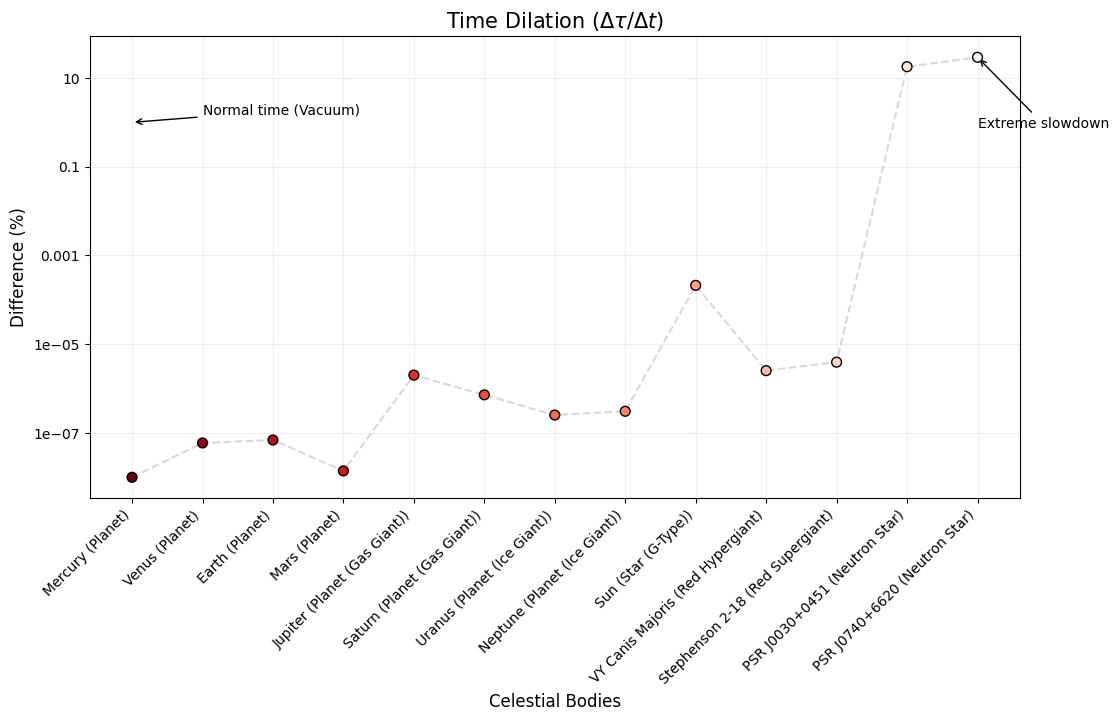

In [42]:
plt.figure(figsize=(12, 6))
plt.title('Time Dilation ($\Delta\\tau / \Delta t$)', fontsize=15)
plt.ylabel('Difference (%)', fontsize=12)
plt.xlabel('Celestial Bodies', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', which='both', linestyle='--', alpha=0.5)
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:g}'))

labels = df_results.index.values
values = df_results['time_dilation']

colors = plt.cm.Reds_r(np.linspace(0, 1, len(labels)))

plt.plot(labels, values, color='gray', linestyle='--', alpha=0.3)
plt.scatter(labels, values, color=colors, s=50, zorder=5, edgecolor='black')

plt.annotate('Normal time (Vacuum)',
             xy=(0, 1.0),
             xytext=(1, 1.5),
             arrowprops=dict(arrowstyle='->'))

plt.annotate('Extreme slowdown',
             xy=(labels[-1], values[-1]),
             xytext=(labels[-1], 0.75),
             arrowprops=dict(arrowstyle='->'))

plt.show()

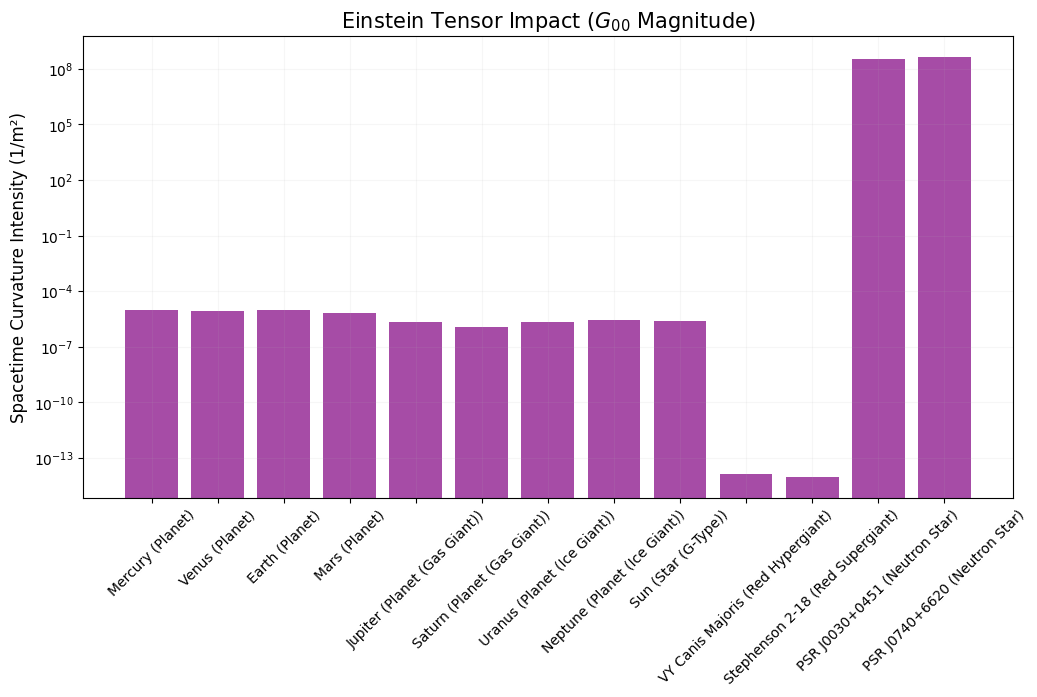

In [43]:
plt.figure(figsize=(12, 6))
plt.title('Einstein Tensor Impact ($G_{00}$ Magnitude)', fontsize=15)
plt.ylabel('Spacetime Curvature Intensity (1/m²)', fontsize=12)
plt.xticks(rotation=45)

plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.1)

labels = df_results.index.values
values = df_results['G_00']
plt.bar(labels, values, color='purple', alpha=0.7)

plt.show()

### Spacetime Distortion (The Einstein "Well")

* **Energy Binding:** In physics, a negative value represents a **Potential Well**. It signifies that an object is "trapped" by gravity and must gain energy to climb back out to "zero" (flat space).
* **Metric Convention:** In General Relativity, the distortion of the time component ($g_{00}$) acts as a subtraction from the flat-space rate. Plotting it negatively helps visualize the **depth of the gravitational field**.
* **Visual Logic:** It aligns with the standard "rubber sheet" analogy where mass creates a dip, not a peak, in the fabric of the universe.

**The Geometry of the Deep Well:**

* **The -10.05 limit:** This value is a mathematical constant for any object when probed at $1.01 \cdot r_s$. It represents a massive **Time Dilation** where 1 second for an observer near the RS would correspond to ~10 seconds for someone far away.
* **Visualization Paradox:** On a linear scale, Earth's gravity is "invisible" because the mass is too spread out. To see the curve, we must either zoom in on the 9th decimal digit of the Y-axis or use a Logarithmic X-axis to bridge the gap between millimeters (RS) and kilometers (Surface).


In [44]:
# Visual simulation of spacetime hole
def plot_spacetime_distortion(body_type, name, mass, radius, density):
    is_planet = "Planet" in body_type
    curvature_too_small = is_planet or density < 10000
    
    plt.figure(figsize=(15, 5))
    if curvature_too_small:
        plt.title(f"{name} - Spacetime Distortion (The Einstein \"Well\")", fontsize=14)
    else:
        plt.title(f"{name} - Spacetime Distortion (The Einstein \"Well\") - Logarithm", fontsize=14)
    
    plt.yticks([-i for i in range(0, 11)])
    plt.ylabel('Spacetime Stretching Factor')
    plt.xlabel('Distance from center (km)')

    # Schwarzschild radius
    rs = (2 * G_const * mass) / (c_const**2)

    start_point = rs * 1.01
    end_point = radius * 1.5
    if is_planet and radius < 10000:
        end_point = radius * 10
    
    r = np.linspace(start_point, end_point, 10000)
    
    # curvature from the metric tensor
    curvature = -1 / (np.sqrt(1 - rs/r))
    
    # plot the curvature
    plt.plot(r/1000, curvature, color='red', lw=2)
    plt.fill_between(r/1000, curvature, color='red', alpha=0.1)

    # references lines
    plt.axvline(x=radius/1000, color='black', linestyle='--', label=f"Surface ({radius/1000:.1f} km)")
    
    # zoom if the curvature is very smalls
    if curvature_too_small or abs(min(curvature)) > 10:
        plt.ylim(min(curvature) * 1.2, -0.9)
    else:
        plt.ylim(min(curvature) - (abs(min(curvature))*0.0001), -0.9)

    if curvature_too_small:
        plt.xscale('log')
    
    # plt.ylim(-10.6, 0)
    
    # show Schwarzschild radius in the legend
    rs_patch = mpatches.Patch(color='none', label=f"Schwarzschild Radius ({rs:.5f} m)")
    current_handles, current_labels = plt.gca().get_legend_handles_labels()
    current_handles.append(rs_patch)
    plt.legend(handles=current_handles)

    plt.show()

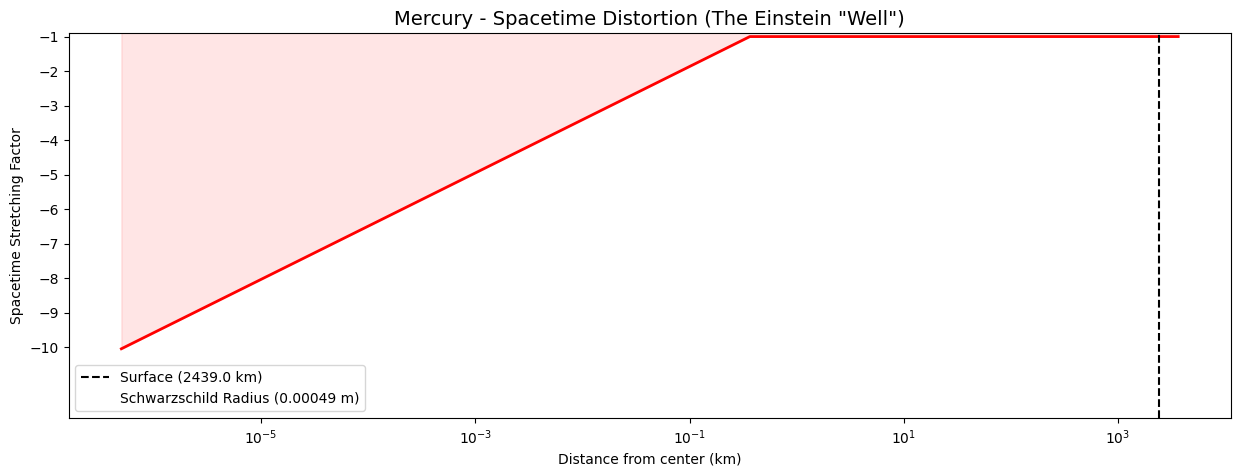

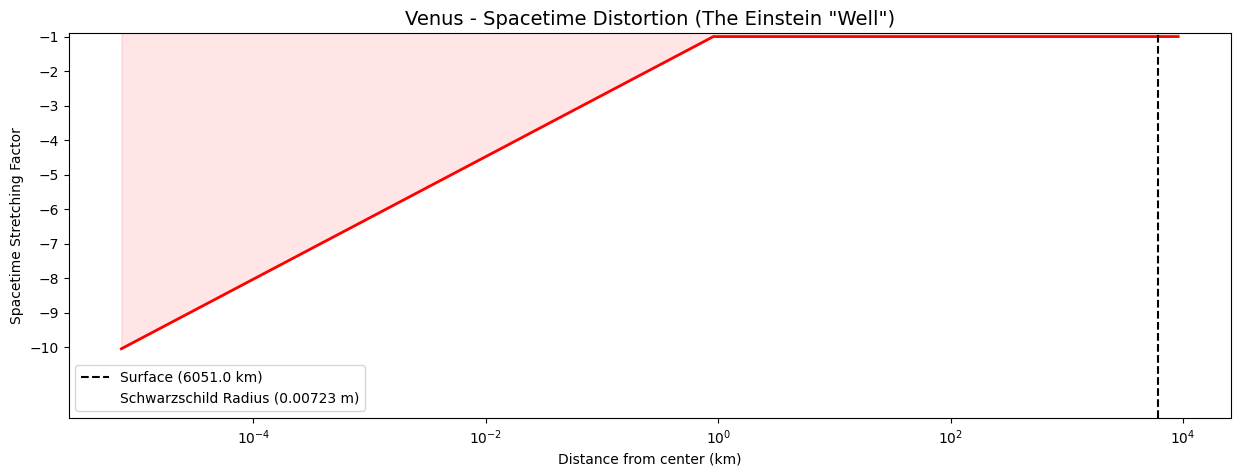

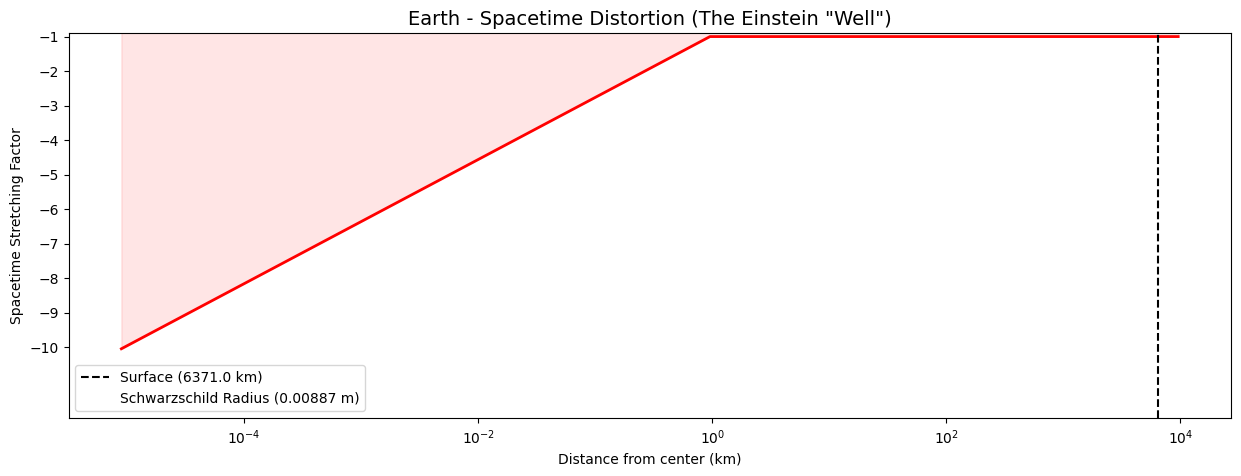

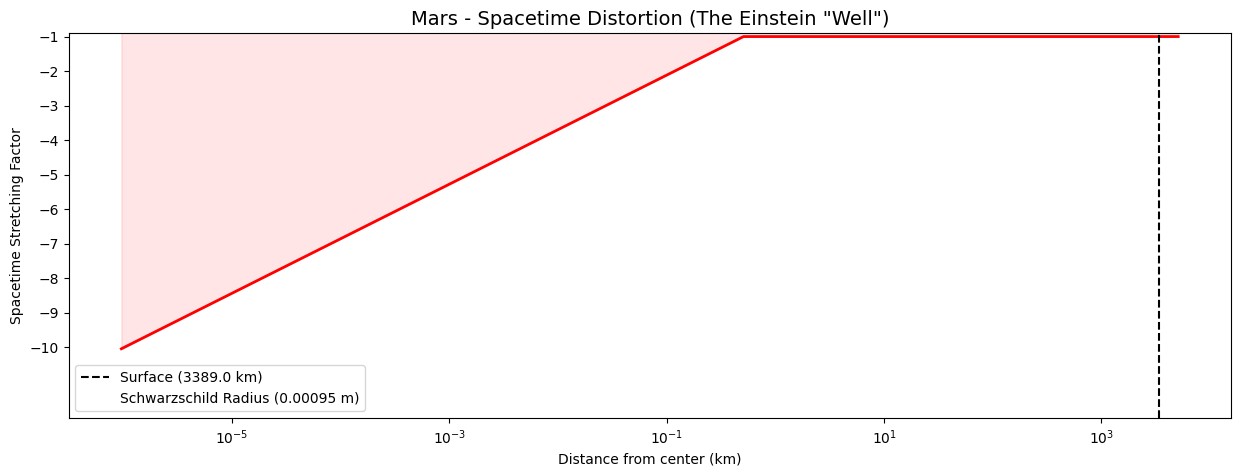

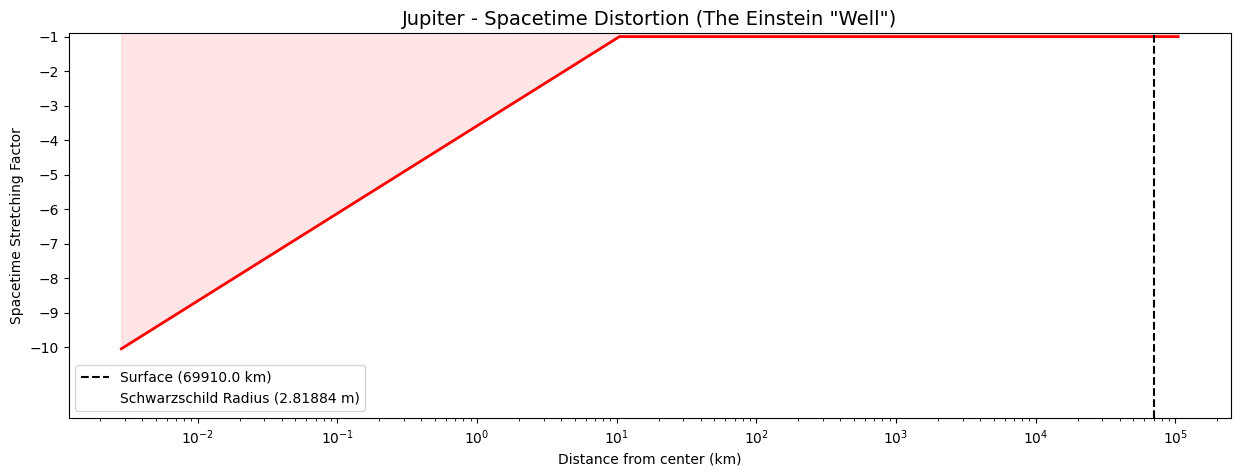

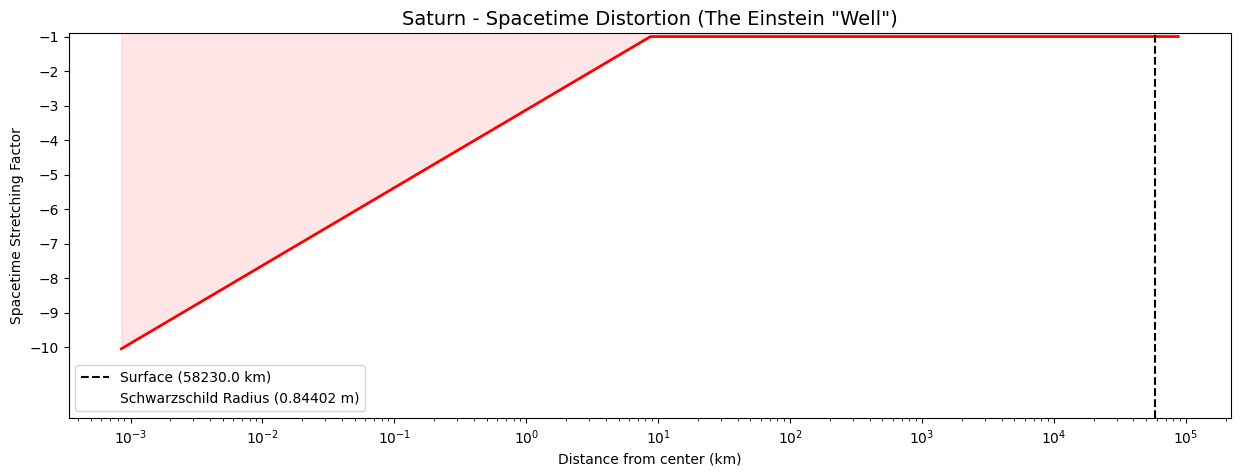

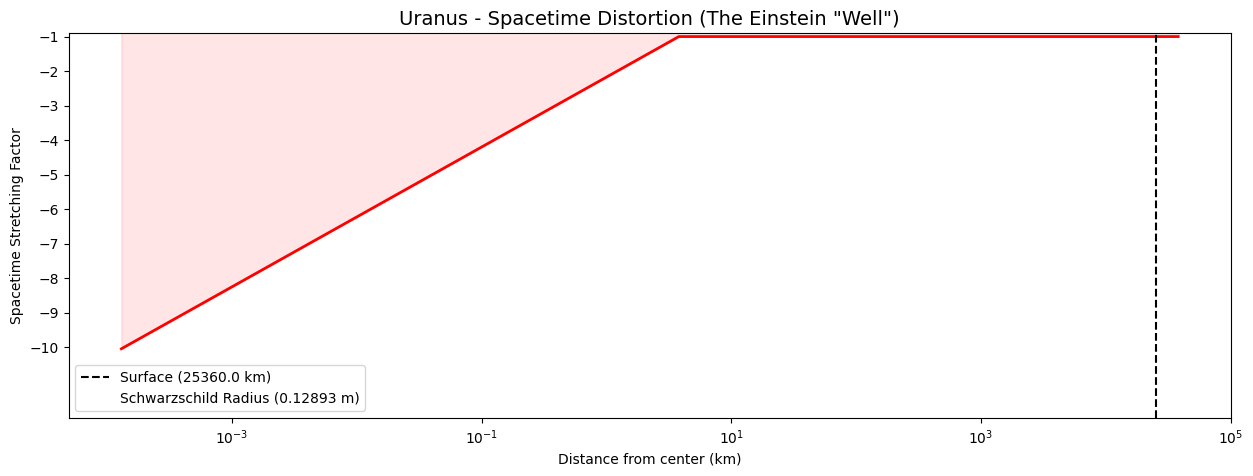

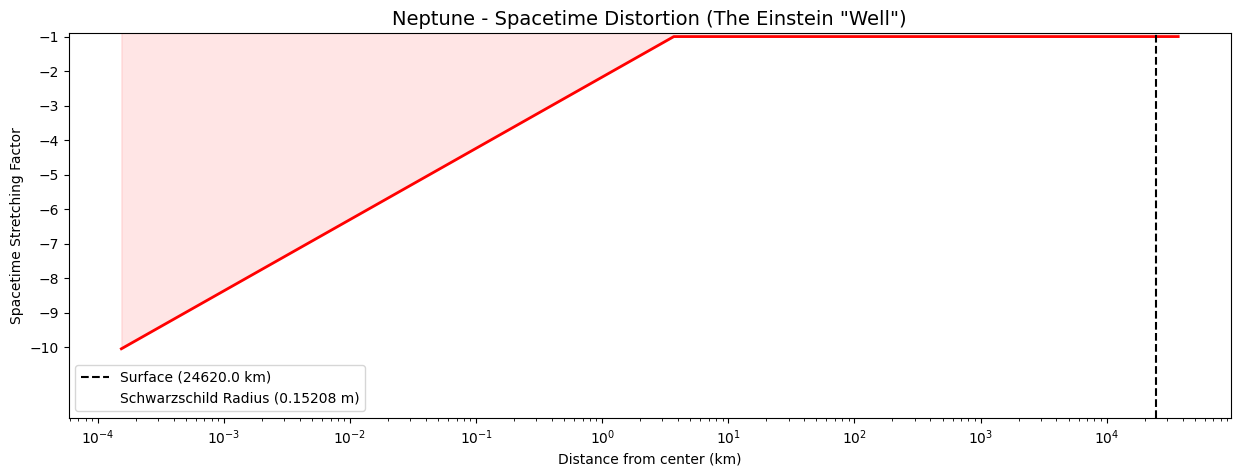

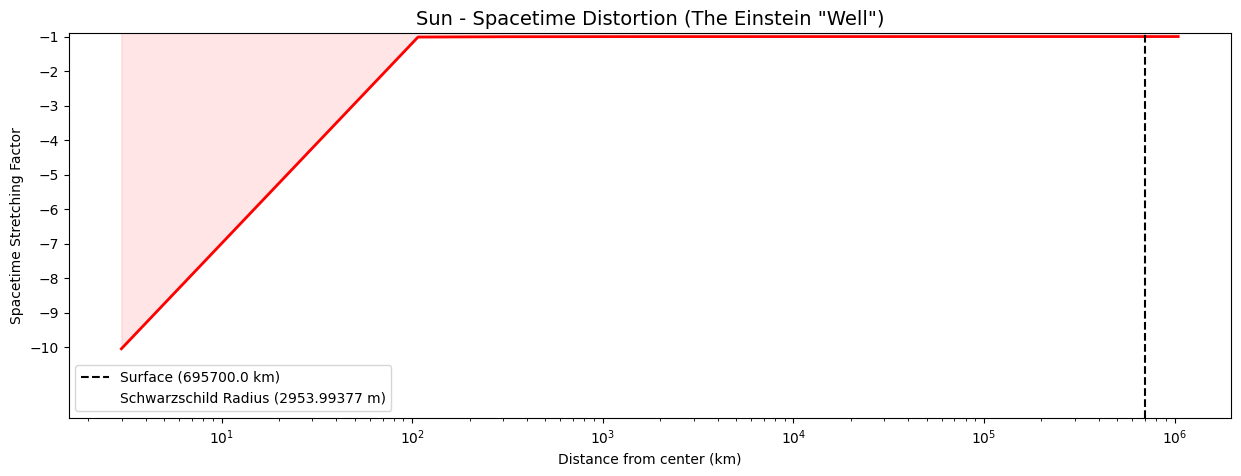

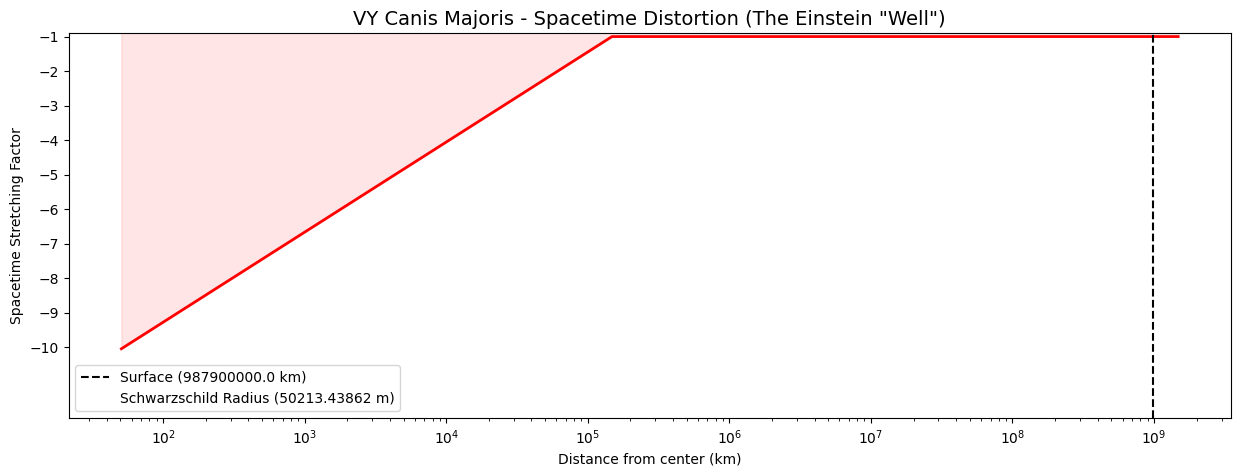

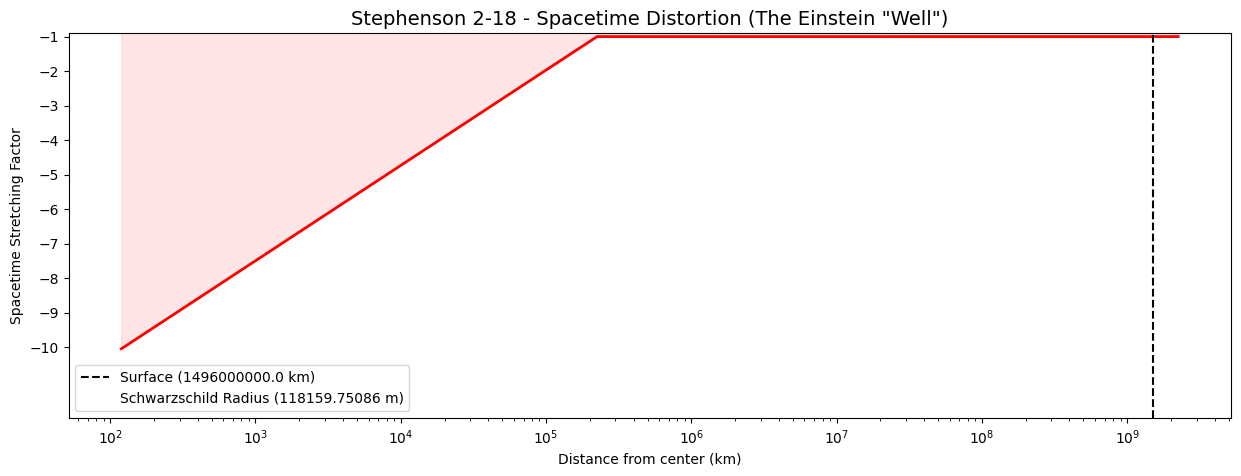

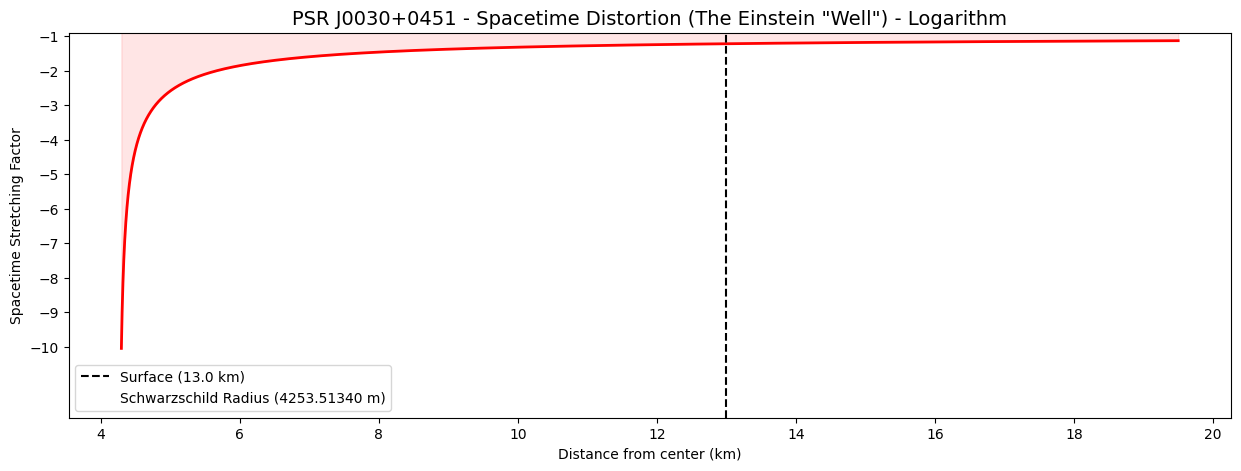

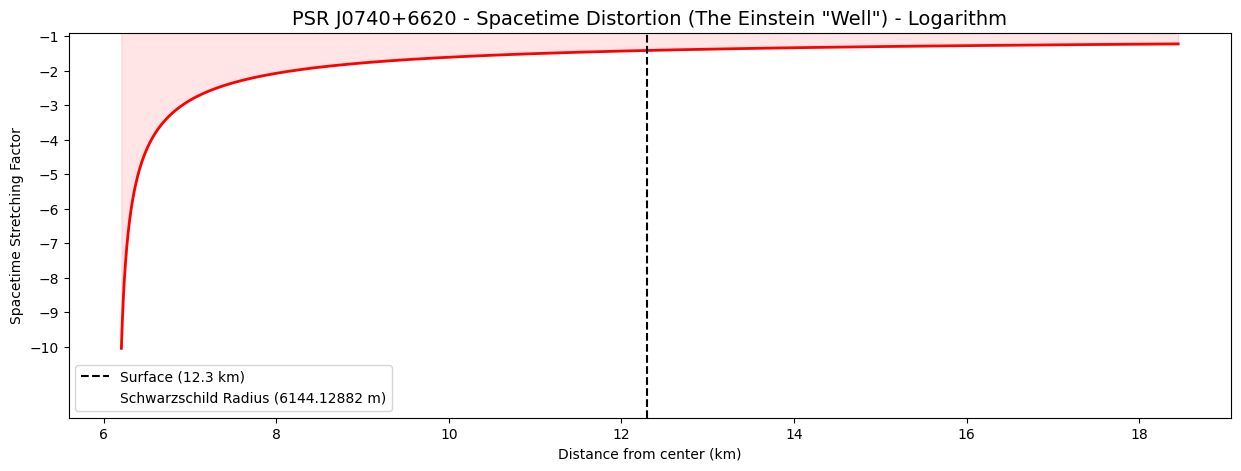

In [45]:
for body in celestial_bodies:
    plot_spacetime_distortion(body['type'], body['name'], body['M'], body['R'], body['rho'])